In [1]:
install.packages("grf")

library(grf)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [2]:
df <- read.csv("./final.csv")

# Convert datetime
df$datetime <- as.POSIXct(df$datetime)

# Create features
df$hour <- as.numeric(format(df$datetime, "%H"))


In [3]:
Y <- df$wdLoad
T <- df$temp

X <- as.matrix(df[, c("hour", "rh")])

In [4]:
# Identify rows with NA values in any of the columns used for Y, T, or X.
# These columns are 'wdLoad', 'temp', 'hour', and 'rh'.
complete_cases_idx <- complete.cases(df[, c("wdLoad", "temp", "hour", "rh")])

# Filter the dataframe to include only rows with complete observations
df_filtered <- df[complete_cases_idx, ]

# Re-define Y, T, and X using the filtered dataframe
Y_filtered <- df_filtered$wdLoad
T_filtered <- df_filtered$temp
X_filtered <- as.matrix(df_filtered[, c("hour", "rh")])

# Now, call causal_forest with the filtered data
cf_temp <- causal_forest(X_filtered, Y_filtered, T_filtered, num.trees = 200)

cat("NA values handled. causal_forest model created successfully with", nrow(df_filtered), "complete observations.\n")

NA values handled. causal_forest model created successfully with 288897 complete observations.


In [5]:
tau_temp <- predict(cf_temp)$predictions

cat("ATE (Temp):", mean(tau_temp), "\n")

ATE (Temp): 9.606032 


In [14]:
cf_temp1 <- causal_forest(X_filtered, Y_filtered, T_filtered, num.trees = 500)

In [15]:
tau_temp1 <- predict(cf_temp1)$predictions

cat("ATE (Temp):", mean(tau_temp1), "\n")

ATE (Temp): 9.605233 


In [22]:
head(tau_temp)
length(tau_temp)

[1] 7.414665 7.252085 6.566243 8.974745 7.735486 7.647899

[1] 288897

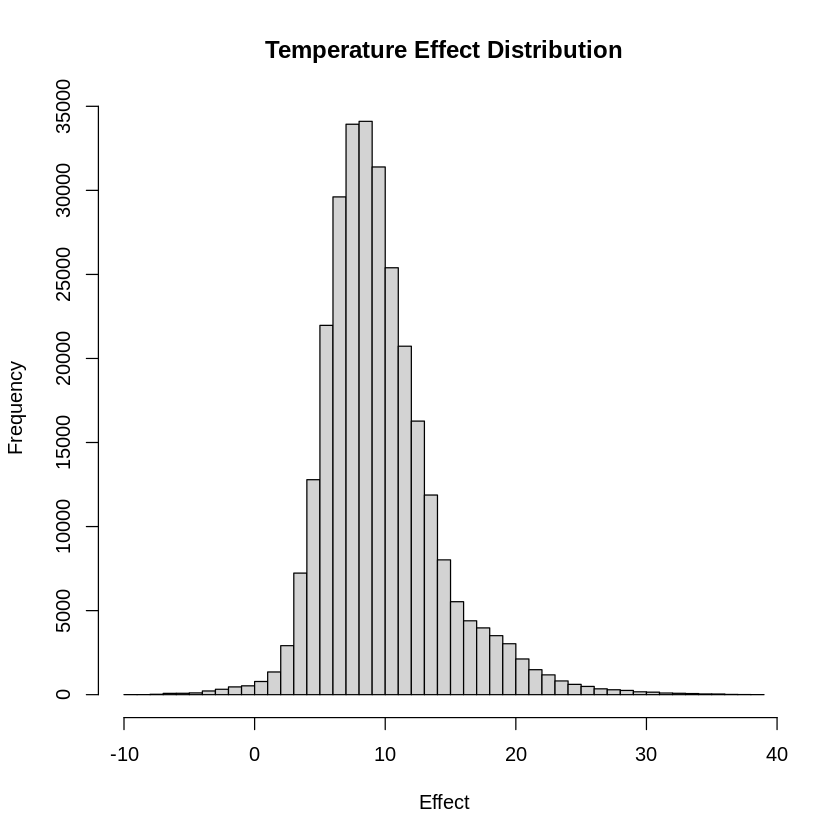

In [6]:
hist(tau_temp, breaks=50,
     main="Temperature Effect Distribution",
     xlab="Effect")

In [18]:
library(dplyr)

df$effect_temp <- tau_temp

effect_by_hour <- df %>%
  group_by(hour) %>%
  summarise(mean_effect = mean(effect_temp))

plot(effect_by_hour$hour, effect_by_hour$mean_effect,
     type="b",
     main="Temp Effect by Hour",
     xlab="Hour",
     ylab="Effect")

ERROR: Error in `$<-.data.frame`(`*tmp*`, effect_temp, value = c(7.41466544765204, : replacement has 288897 rows, data has 288911


In [12]:
T_rh <- df$rh

X_rh <- as.matrix(df[, c("hour", "temp")])

In [13]:
Y_for_rh_cf <- df_filtered$wdLoad
T_for_rh_cf <- df_filtered$rh
X_for_rh_cf <- as.matrix(df_filtered[, c("hour", "temp")])

cf_rh <- causal_forest(X_for_rh_cf, Y_for_rh_cf, T_for_rh_cf, num.trees = 500)

tau_rh <- predict(cf_rh)$predictions

cat("ATE (Humidity):", mean(tau_rh), "\n")

ATE (Humidity): 0.516365 


In [17]:
cf_rh1 <- causal_forest(X_for_rh_cf, Y_for_rh_cf, T_for_rh_cf, num.trees = 200)

tau_rh1 <- predict(cf_rh1)$predictions

cat("ATE (Humidity):", mean(tau_rh1), "\n")

ATE (Humidity): 0.5137415 
